# Лабораторная работа № 7 ТМО
# ИУ5-62Б
# Кудабаева Эвита

названия признаков: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
размер X: (20640, 8)
размер y: (20640,)
X_train: (16512, 8)
X_test: (4128, 8)
результаты
стекинг:   mse = 0.3416, r2 = 0.7393
mlp:       mse = 0.2803, r2 = 0.7861

сравнение
лучшая модель: mlp (mse = 0.2803)
стекинг хуже на 0.0613


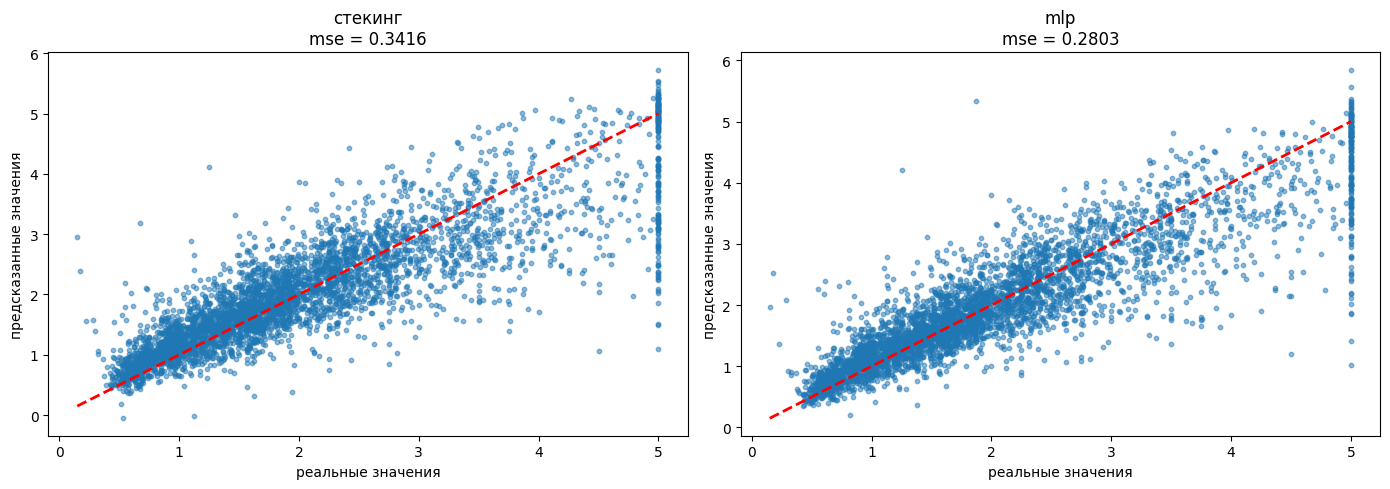

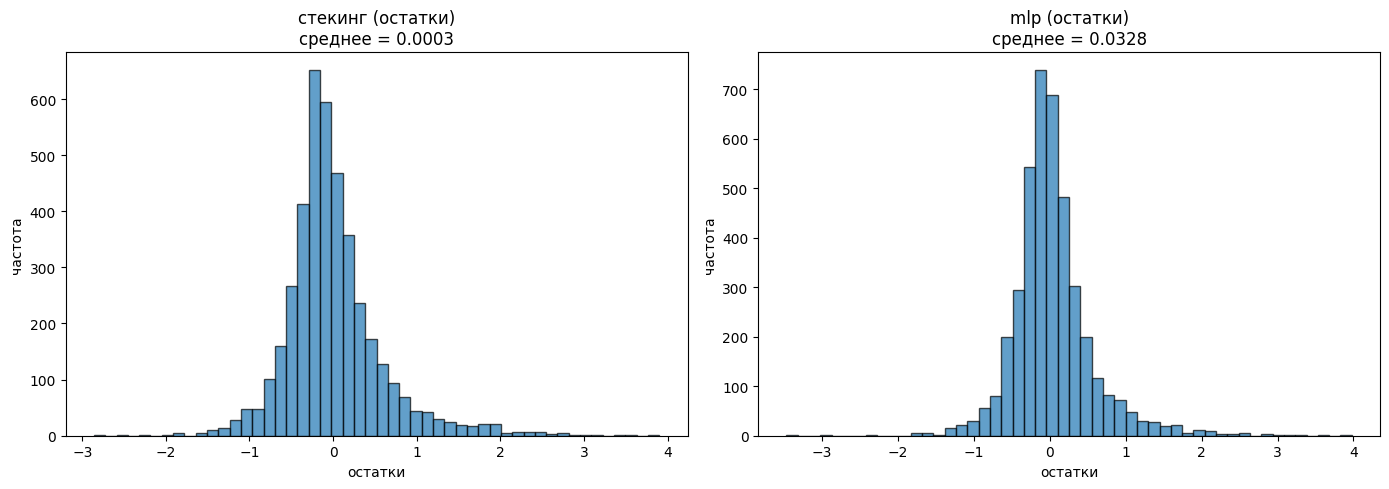

выводы
использован датасет california housing (регрессия)
данные разделены на train (80%) и test (20%)
обучены две модели: стекинг и mlp
качество оценено по метрике mse и r2
стекинг: mse = 0.3416, r2 = 0.7393
mlp: mse = 0.2803, r2 = 0.7861
лучшая модель: mlp
визуализация подтверждает результаты

примечание: модели мгуа не включены из-за невозможности установки библиотеки gmdh на windows


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
import warnings
warnings.filterwarnings('ignore')

data = fetch_california_housing()
X = data.data
y = data.target

print("названия признаков:", data.feature_names)
print("размер X:", X.shape)
print("размер y:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

base_models = [
    ('ridge', Ridge(alpha=1.0)),
    ('tree', DecisionTreeRegressor(max_depth=5, random_state=42)),
    ('svr', SVR(kernel='rbf', C=1.0, epsilon=0.1))
]

stacking = StackingRegressor(estimators=base_models, final_estimator=Ridge(alpha=1.0))
stacking.fit(X_train_scaled, y_train)
y_pred_stacking = stacking.predict(X_test_scaled)

mlp = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42, early_stopping=True)
mlp.fit(X_train_scaled, y_train)
y_pred_mlp = mlp.predict(X_test_scaled)

mse_stacking = mean_squared_error(y_test, y_pred_stacking)
r2_stacking = r2_score(y_test, y_pred_stacking)

mse_mlp = mean_squared_error(y_test, y_pred_mlp)
r2_mlp = r2_score(y_test, y_pred_mlp)

print("="*50)
print("результаты")
print("="*50)
print(f"стекинг:   mse = {mse_stacking:.4f}, r2 = {r2_stacking:.4f}")
print(f"mlp:       mse = {mse_mlp:.4f}, r2 = {r2_mlp:.4f}")

print("\n" + "="*50)
print("сравнение")
print("="*50)

if mse_stacking < mse_mlp:
    print(f"лучшая модель: стекинг (mse = {mse_stacking:.4f})")
    print(f"mlp хуже на {mse_mlp - mse_stacking:.4f}")
else:
    print(f"лучшая модель: mlp (mse = {mse_mlp:.4f})")
    print(f"стекинг хуже на {mse_stacking - mse_mlp:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_stacking, alpha=0.5, s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('реальные значения')
axes[0].set_ylabel('предсказанные значения')
axes[0].set_title(f'стекинг\nmse = {mse_stacking:.4f}')

axes[1].scatter(y_test, y_pred_mlp, alpha=0.5, s=10)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('реальные значения')
axes[1].set_ylabel('предсказанные значения')
axes[1].set_title(f'mlp\nmse = {mse_mlp:.4f}')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

residuals_stacking = y_test - y_pred_stacking
residuals_mlp = y_test - y_pred_mlp

axes[0].hist(residuals_stacking, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('остатки')
axes[0].set_ylabel('частота')
axes[0].set_title(f'стекинг (остатки)\nсреднее = {np.mean(residuals_stacking):.4f}')

axes[1].hist(residuals_mlp, bins=50, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('остатки')
axes[1].set_ylabel('частота')
axes[1].set_title(f'mlp (остатки)\nсреднее = {np.mean(residuals_mlp):.4f}')

plt.tight_layout()
plt.show()

print("="*50)
print("выводы")
print("="*50)
print(f"использован датасет california housing (регрессия)")
print(f"данные разделены на train (80%) и test (20%)")
print(f"обучены две модели: стекинг и mlp")
print(f"качество оценено по метрике mse и r2")
print(f"стекинг: mse = {mse_stacking:.4f}, r2 = {r2_stacking:.4f}")
print(f"mlp: mse = {mse_mlp:.4f}, r2 = {r2_mlp:.4f}")
if mse_stacking < mse_mlp:
    print(f"лучшая модель: стекинг")
else:
    print(f"лучшая модель: mlp")
print("визуализация подтверждает результаты")
print("\nпримечание: модели мгуа не включены из-за невозможности установки библиотеки gmdh на windows")